<a href="https://colab.research.google.com/github/KULDEEPSONI-source/MACHINE-LEARNING/blob/main/clusters_in_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Clustering is a fundamental technique in **unsupervised machine learning** used to group a set of objects in such a way that objects in the same group (called a **cluster**) are more similar to each other than to those in other groups.

Since the data is "unlabeled" (there are no pre-defined categories), the algorithm discovers the natural structures or patterns within the data on its own.

---

### Core Objectives

* **Intra-cluster similarity:** Maximize the similarity between data points within the same cluster.
* **Inter-cluster dissimilarity:** Maximize the distance between different clusters.

---

### Common Clustering Algorithms

| Algorithm | How it Works | Best Used For |
| --- | --- | --- |
| **K-Means** | Partitions data into $K$ predefined clusters by minimizing the variance within each cluster. | Large datasets where clusters are spherical and clearly separated. |
| **Hierarchical** | Creates a tree-like structure (dendrogram) of clusters by either merging or splitting them. | Discovering taxonomy or nested groupings in data. |
| **DBSCAN** | Groups points that are packed closely together; marks points in low-density regions as outliers. | Identifying clusters of arbitrary shapes and handling noise/outliers. |

---

### Real-World Applications

* **Customer Segmentation:** Grouping customers based on purchasing behavior for targeted marketing.
* **Image Compression:** Reducing the number of colors in an image by grouping similar pixel colors.
* **Anomaly Detection:** Identifying data points that do not fit into any cluster, which often signifies fraud or system errors.
* **Recommendation Systems:** Finding groups of users with similar preferences to suggest relevant content.

---

### Key Challenges

1. **Choosing 'K':** In many algorithms like K-Means, you must decide the number of clusters beforehand.
2. **Feature Scaling:** Because clustering relies on distance metrics (like Euclidean distance), data must be scaled so that features with larger ranges don't dominate the results.
3. **High Dimensionality:** As the number of features increases, the concept of "distance" becomes less meaningful (the "curse of dimensionality").



---
---
---
**K-Means** is one of the most popular and intuitive **centroid-based clustering algorithms**. It aims to partition $n$ observations into $K$ distinct, non-overlapping clusters, where each data point belongs to the cluster with the nearest mean (the centroid).

---

### How K-Means Works (The Algorithm)

The process is iterative and follows these primary steps:

1. **Initialization:** Choose the number of clusters, $K$. Randomly select $K$ initial points in the data space to serve as the starting **centroids**.
2. **Assignment:** Assign each data point to the closest centroid, typically using **Euclidean distance**. This creates $K$ clusters.
3. **Update:** Calculate the new mean (center) of all data points assigned to each cluster. Move the centroids to these new locations.
4. **Repeat:** Repeat the **Assignment** and **Update** steps until the centroids no longer move significantly or a maximum number of iterations is reached (convergence).

---

### Mathematical Goal

The algorithm minimizes the **Within-Cluster Sum of Squares (WCSS)**, also known as **Inertia**. The objective is to minimize:

$$\sum_{i=1}^{K} \sum_{x \in C_i} ||x - \mu_i||^2$$

* $C_i$: The $i$-th cluster.
* $\mu_i$: The mean (centroid) of the $i$-th cluster.
* $x$: A data point in that cluster.

---

### Pros and Cons

| **Pros** | **Cons** |
| --- | --- |
| **Efficiency:** Computationally fast and easy to implement. | **K-Dependency:** You must specify the number of clusters ($K$) in advance. |
| **Scalability:** Performs well on large datasets. | **Sensitivity:** Sensitive to initial random centroid placement and outliers. |
| **Simplicity:** Produces tight, spherical clusters that are easy to interpret. | **Shape Limitation:** Struggles with complex, non-spherical, or overlapping cluster shapes. |

---

### Determining the Optimal K

Since $K$ is a hyperparameter, it is often determined using the **Elbow Method**:

* Plot the WCSS (Inertia) against a range of $K$ values.
* The point where the rate of decrease shifts sharply (the "elbow") typically represents the optimal number of clusters for the data.

---
---
---


# K-MEANS (IN PY)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
dataset = pd.read_csv('/content/mall.csv')

In [5]:
dataset.head(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
X= dataset.iloc[:,[3,4]].values

In [7]:
X

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

----
----
---
---
This code snippet is the standard implementation of the **Elbow Method** to find the optimal number of clusters ($K$) for your dataset.

Here is the breakdown of the parameters used in the `KMeans` class and the plotting functions:

### 1. The `KMeans` Class Parameters

```python
kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)

```

* **`n_clusters=i`**: This is the most important parameter. It defines the number of clusters you want the algorithm to form. In your loop, it iterates from 1 to 10 to see how the model performs for each $K$.
* **`init='k-means++'`**: This selects the initial cluster centers in a smart way to speed up convergence. Instead of placing them randomly, it chooses the first centroid randomly and then selects subsequent centroids that are far away from the existing ones. This helps avoid the "random initialization trap" where the algorithm gets stuck in a poor solution.
* **`random_state=42`**: This ensures **reproducibility**. Because K-Means starts with random centroid placements, setting a seed (like 42) ensures that you get the exact same results every time you run the code, which is vital for debugging and comparing experiments.

---

### 2. The `fit` Method and `inertia_`

```python
kmeans.fit(X)
wcss.append(kmeans.inertia_)

```

* **`fit(X)`**: This command triggers the training process. The algorithm computes the distances and iteratively updates the centroids based on the data points in $X$.
* **`kmeans.inertia_`**: This is the attribute that stores the **WCSS (Within-Cluster Sum of Squares)**. It is the sum of squared distances of samples to their closest cluster center. As you increase the number of clusters, this value will naturally decrease because data points become closer to their respective centroids.

---

### 3. Plotting Parameters

```python
plt.plot(range(1,11), wcss)
plt.title('Elbow Method')
plt.xlabel('Clusters')
plt.ylabel('WCSS')
plt.show()

```

* **`plt.plot(range(1,11), wcss)`**: Plots the $K$ values (x-axis) against the resulting inertia (y-axis).
* **`plt.title`, `plt.xlabel`, `plt.ylabel**`: These are labels to make your graph interpretable. The "Elbow" is the point where the curve starts to flatten out (the point of diminishing returns), which is your ideal $K$.

---

### Quick Summary of Logic

1. **The Loop:** You are training 10 different versions of K-Means.
2. **The Metric:** You track `inertia_` (WCSS) for each version.
3. **The Visualization:** You look for the "elbow"—the point where adding another cluster doesn't significantly reduce the WCSS anymore.

**Note:** In modern versions of Scikit-Learn, you may want to add `n_init='auto'` or specify `n_init=10` to avoid warnings, as the default initialization behavior changes occasionally in library updates.
----
---
---


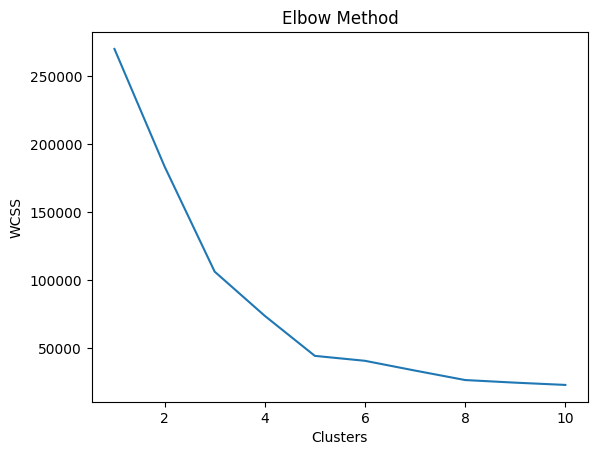

In [10]:
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
  kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss)
plt.title('Elbow Method')
plt.xlabel('Clusters')
plt.ylabel('WCSS')
plt.show()

In [11]:
kmeans = KMeans(n_clusters=6)
y_kmeans= kmeans.fit_predict(X)

---
---
---
This code snippet is used to **visualize the final clustering results** in a 2D scatter plot. It maps your data points into distinct colors based on their assigned cluster and highlights the center of each cluster.

Here is the breakdown of the syntax and logic:

### 1. `plt.scatter(...)` breakdown

You are calling `plt.scatter` multiple times to layer different groups on the same plot.

* **`X[y_kmeans == i, 0]`**: This selects the data points belonging to cluster `i`.
* The `y_kmeans == i` is a **boolean mask** that filters only the rows where the cluster label matches `i`.
* The index `, 0` selects the **first feature** (e.g., Annual Income).


* **`X[y_kmeans == i, 1]`**: Selects the **second feature** (e.g., Spending Score) for the same cluster `i`.
* **`s=100`**: Defines the **size** of the data points.
* **`c='color'`**: Sets the color for that specific cluster, helping distinguish them visually.
* **`label='Cluster X'`**: Sets the name for the legend entry.

### 2. Plotting the Centroids

```python
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='black', label='Centroids')

```

* **`kmeans.cluster_centers_`**: This attribute holds the coordinates of the final centroids calculated by the algorithm.
* **`[:, 0]` and `[:, 1]**`: Plots the $x$ and $y$ coordinates of all centroids at once.
* **`s=300`**: Makes the centroids significantly larger than the data points (`s=100`) so they stand out as the "heart" of each cluster.

### 3. Formatting

* **`plt.title`, `plt.xlabel`, `plt.ylabel**`: Provides context, identifying that this plot likely represents a **Customer Segmentation** model based on income and spending habits.
* **`plt.legend()`**: Automatically generates the legend box using the `label` arguments you provided in the `scatter` calls.
* **`plt.show()`**: Renders the final figure.

---

### Important Considerations for this Code:

* **Dimension Limitation:** This code assumes `X` is a 2D array (only two features). If your dataset has more than two features, you would need to use **dimensionality reduction** techniques like **PCA (Principal Component Analysis)** to squash the data into 2D before plotting it this way.
* **Dynamic Colors:** If you increase the number of clusters (`K`) beyond 6, you will need to manually add more `plt.scatter` lines or use a colormap loop to handle the colors automatically.
---
---
---


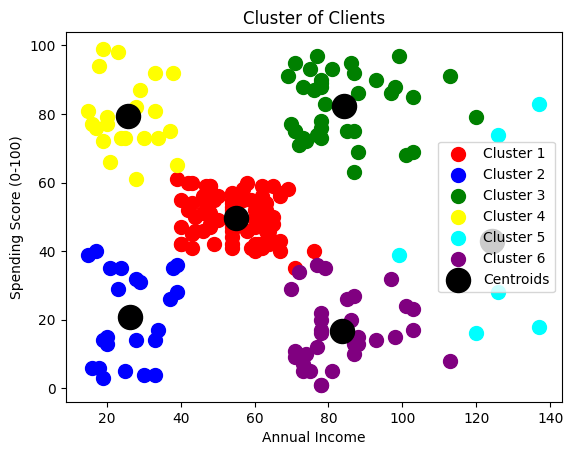

In [19]:
plt.scatter(X[y_kmeans == 0,0], X[y_kmeans == 0,1], s=100, c='red', label='Cluster 1')
plt.scatter(X[y_kmeans == 1,0], X[y_kmeans == 1,1], s=100, c='blue', label='Cluster 2')
plt.scatter(X[y_kmeans == 2,0], X[y_kmeans == 2,1], s=100, c='green', label='Cluster 3')
plt.scatter(X[y_kmeans == 3,0], X[y_kmeans == 3,1], s=100, c='yellow', label='Cluster 4')
plt.scatter(X[y_kmeans == 4,0], X[y_kmeans == 4,1], s=100, c='cyan', label='Cluster 5')
plt.scatter(X[y_kmeans == 5,0], X[y_kmeans == 5,1], s=100, c='purple', label='Cluster 6')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=300, c='black', label='Centroids')

plt.title('Cluster of Clients')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score (0-100)')
plt.legend()
plt.show()

---
---
---
---
**Hierarchical Clustering** is an unsupervised learning algorithm that builds a tree of clusters rather than partitioning data into a single set of clusters (like K-Means). It is particularly useful when you want to understand the **taxonomy** or hierarchical relationships within your data.

There are two primary approaches to building this hierarchy:

### 1. The Two Main Strategies

* **Agglomerative (Bottom-Up):** The most common approach. Every data point starts as its own individual cluster. The algorithm then iteratively merges the two closest clusters until only one large cluster remains.
* **Divisive (Top-Down):** The inverse approach. All data points start in one single cluster, and the algorithm recursively splits the clusters until every data point is in its own cluster.

---

### 2. Key Components

* **Dendrogram:** This is a tree-like diagram that records the sequences of merges or splits. The horizontal axis represents the data points, and the vertical axis represents the distance (dissimilarity) at which clusters were merged.
* **Linkage Criteria:** This defines how the distance between two clusters is calculated. Common methods include:
* **Single Linkage:** The distance between the *closest* points of two clusters.
* **Complete Linkage:** The distance between the *farthest* points of two clusters.
* **Average Linkage:** The average distance between all points in two clusters.
* **Ward’s Method:** Minimizes the variance within the clusters (very common).



---

### 3. Pros and Cons

| **Pros** | **Cons** |
| --- | --- |
| **No 'K' Required:** You don't need to specify the number of clusters in advance; you can "cut" the tree at any level to get your desired number. | **Computational Cost:** It is very slow on large datasets ($O(n^3)$ or $O(n^2 \log n)$ complexity). |
| **Interpretability:** The dendrogram provides a clear visual representation of data relationships. | **Sensitivity:** Sensitive to noise and outliers, which can affect the tree structure significantly. |

---

### When to use Hierarchical over K-Means?

Use **Hierarchical Clustering** when:

1. You do not know the number of clusters beforehand.
2. You need to visualize the relationships between clusters (the dendrogram).
3. Your dataset is small enough to handle the high computational load.
---
---
---
---

#  HC IN PY


In [20]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [21]:
# Reading the data
dataset = pd.read_csv('/content/mall.csv')

In [22]:
dataset.head(5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [23]:
X = dataset.iloc[:,[3,4]].values


---
---
---
---
---
This code is used to create a **Dendrogram**, which helps you decide the optimal number of clusters for **Agglomerative Hierarchical Clustering**.

Here is the breakdown of the parameters and the logic behind this visualization:

### 1. `sch.linkage(X, method='ward')`

* **`X`**: Your dataset.
* **`method='ward'`**: This specifies the linkage criterion. Ward's method minimizes the variance within each cluster. It is generally the most popular choice because it produces compact, evenly sized clusters and effectively avoids the "chaining" effect (where clusters become long and thin).

### 2. `sch.dendrogram(...)`

* This function takes the linkage matrix produced by the previous step and draws the tree-like structure.
* **The X-axis:** Represents the individual data points (customers).
* **The Y-axis:** Represents the **Euclidean distance** between clusters. The higher the horizontal line, the larger the distance at which two clusters were merged.

---

### How to use this to find the "Optimal K"

To determine the optimal number of clusters, follow these steps:

1. **Find the largest vertical line:** Look for the longest vertical segment that does not cross any horizontal lines.
2. **Draw a horizontal line:** Draw a horizontal line through that vertical segment.
3. **Count the intersections:** Count how many vertical lines your horizontal line crosses. That count is your **optimal number of clusters ($K$)**.

### Code Summary

* **`plt.title`, `plt.xlabel`, `plt.ylabel**`: Standard labeling to keep your analysis clear.
* **`plt.show()`**: Renders the diagram.

---

### Important Note

Hierarchical clustering is computationally intensive. If your dataset $X$ is very large (e.g., tens of thousands of rows), this `dendrogram` function will be extremely slow to compute and difficult to read. In those cases, researchers often use **K-Means** or **Birch** instead.


---

---
---
---

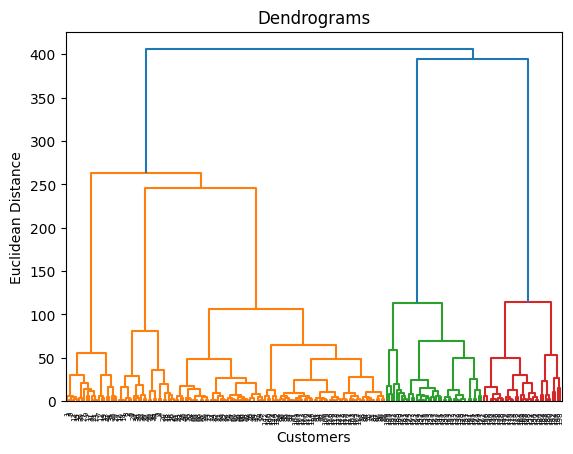

In [24]:
# Using dendogram to find optimal number of clusters

import scipy.cluster.hierarchy as sch
dendogram = sch.dendrogram(sch.linkage(X, method='ward'))
plt.title('Dendrograms')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.show()


In [26]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=5, linkage='ward')
y_hc = hc.fit_predict(X)

---
---
---
---
This code implements the **Agglomerative Hierarchical Clustering** algorithm using the parameters identified from your dendrogram analysis.

### Breakdown of the Code

* **`AgglomerativeClustering(...)`**: This class initializes the model. Unlike K-Means, which uses a centroid-based approach, this is a **bottom-up** approach that merges clusters based on proximity.
* **`n_clusters=5`**: This is the number of clusters you decided upon after analyzing your dendrogram. You are effectively "cutting" the tree at a height that results in 5 distinct groups.
* **`linkage='ward'`**: This must match the method you used in your `sch.linkage` function to ensure consistency. Ward's linkage is the standard choice as it minimizes the sum of squared differences within all clusters.
* **`hc.fit_predict(X)`**: This performs the clustering on your data $X$ and returns an array of cluster labels (0 to 4) for each observation.

---

### Key Difference from K-Means

While K-Means assigns points based on their distance to a "centroid," **Agglomerative Clustering** calculates the distance between all pairs of points (or clusters) and merges them based on the chosen linkage.

### Next Steps for Your Analysis

Now that you have your labels in `y_hc`, you can visualize the results just like you did with K-Means. You would typically use a scatter plot, applying the labels from `y_hc` to color-code the points:

```python
# Example visualization
plt.scatter(X[y_hc == 0, 0], X[y_hc == 0, 1], s=100, c='red', label='Cluster 1')
# ... repeat for other clusters ...
plt.legend()
plt.show()

```

Since this algorithm does not store `cluster_centers_` (because it doesn't use centroids), you won't be able to plot "black dots" for centers as you did with K-Means.
----
----
---
----
----
---

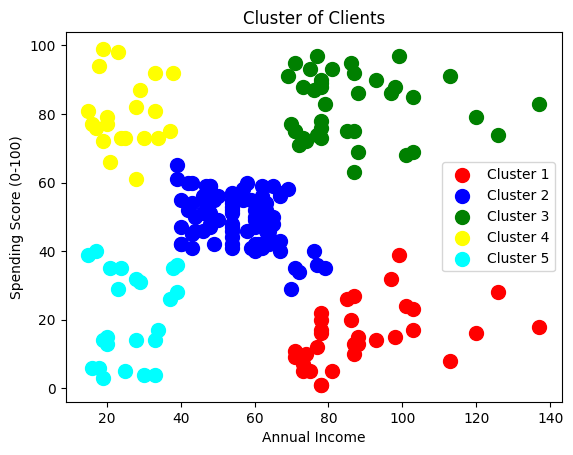

In [28]:
# Visualizing the clusters
# Visualizing the clusters
plt.scatter(X[y_hc == 0,0], X[y_hc == 0,1], s=100, c='red', label='Cluster 1')
plt.scatter(X[y_hc == 1,0], X[y_hc == 1,1], s=100, c='blue', label='Cluster 2')
plt.scatter(X[y_hc == 2,0], X[y_hc == 2,1], s=100, c='green', label='Cluster 3')
plt.scatter(X[y_hc == 3,0], X[y_hc == 3,1], s=100, c='yellow', label='Cluster 4')
plt.scatter(X[y_hc == 4,0], X[y_hc == 4,1], s=100, c='cyan', label='Cluster 5')
# plt.scatter(X[y_hc == 5,0], X[y_hc == 5,1], s=100, c='purple', label='Cluster 6')

plt.title('Cluster of Clients')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score (0-100)')
plt.legend()
plt.show()

# *MEAN SHIFT CLUSTRING*


**Mean Shift Clustering** is a powerful, non-parametric, unsupervised machine learning algorithm. Unlike K-Means, which assumes clusters are spherical and requires you to specify the number of clusters ($K$) beforehand, Mean Shift discovers the number of clusters automatically by finding "dense" regions in the data.

---

### How Mean Shift Works (The Intuition)

Think of Mean Shift as a **"mode-seeking"** algorithm. It treats the data points as a probability density function:

1. **Placement:** You start by placing a circular window (or kernel) over every data point (or a subset of them).
2. **Shifting:** The algorithm calculates the **mean** (average) of all data points within that window.
3. **Moving:** It then "shifts" the center of the window to that calculated mean.
4. **Iteration:** This process repeats iteratively. As the window moves, it naturally gravitates toward the regions where data points are most densely packed.
5. **Convergence:** Once the window stops moving (the mean no longer shifts), it has found a local maximum, or "mode." All points that migrate toward the same mode are grouped into the same cluster.

---

### Key Parameters

* **Bandwidth:** This is the radius of the window used for shifting. It is the **most critical parameter** in Mean Shift.
* If the bandwidth is too small, you will get too many clusters (over-segmentation).
* If the bandwidth is too large, the algorithm will merge distinct clusters together (under-segmentation).



---

### Pros and Cons

| **Pros** | **Cons** |
| --- | --- |
| **No 'K' Required:** Automatically determines the number of clusters based on data density. | **Computationally Expensive:** The iterative shifting process is slow, typically $O(n^2)$ time complexity. |
| **Arbitrary Shapes:** Can identify clusters of complex, non-spherical shapes. | **Bandwidth Sensitivity:** Extremely sensitive to the choice of bandwidth, which is often difficult to select. |
| **Robust to Outliers:** Naturally ignores points in low-density regions. | **Performance:** Struggles with very large datasets due to its high computational requirements. |

---

### When to use Mean Shift?

Mean Shift is an excellent choice for **Computer Vision** tasks, such as object tracking or image segmentation, where the clusters have irregular shapes and you don't know how many objects might be in the frame.

### Comparison Summary

* **K-Means:** Use when you know $K$, want speed, and expect spherical clusters.
* **Hierarchical:** Use when you need a clear visual taxonomy (dendrogram) and have a small dataset.
* **Mean Shift:** Use when you have no idea how many clusters exist and the shapes are irregular.
----
----
----


In [29]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import MeanShift

In [30]:
# Reading the data
dataset = pd.read_csv('/content/mall.csv')

In [31]:
dataset.head(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [32]:
X = dataset.iloc[:,[3,4]].values

----
---
----
---
----
This code implements the **Mean Shift** algorithm. Unlike K-Means, which requires you to pre-define the number of clusters ($K$), Mean Shift automatically finds them based on the density of your data.

### Explanation of the Code

* **`MeanShift(bandwidth=20)`**: This initializes the algorithm. The **`bandwidth`** parameter is the most important setting here. It defines the "radius" of the search window that the algorithm uses to look for data points.
* **Low Bandwidth:** Results in many, smaller clusters because the algorithm is "myopic" and focuses on tiny, dense pockets.
* **High Bandwidth:** Results in fewer, larger clusters because the window is wider and captures more data points into a single mode.
* *Tip:* If you don't know what to set, you can use `sklearn.cluster.estimate_bandwidth(X)` to let the library calculate a reasonable starting value for you.


* **`ms.fit(X)`**: This starts the process. The algorithm iteratively moves the "windows" until they converge on the points of highest density (the "modes").
* **`ms.labels_`**: This array assigns a cluster number to every data point in your dataset $X$.
* **`ms.cluster_centers_`**: This attribute stores the final coordinates where the windows stopped moving (the density peaks).

---

### Key Things to Keep in Mind

1. **Complexity:** Mean Shift is generally slower than K-Means. On the "Mall Customers" dataset (usually ~200 rows), it will run almost instantly, but on datasets with hundreds of thousands of rows, it may be significantly slower.
2. **No 'K' required:** You don't have to guess the number of clusters; the algorithm effectively "discovers" them based on the natural gaps and densities in your data.
3. **The "Mall" Data Context:** Since you are using it on the Mall dataset (Annual Income vs. Spending Score), Mean Shift is actually a very intelligent choice. It can identify non-circular shapes and outliers (like extremely wealthy shoppers or those with zero spending) much more gracefully than K-Means.

### How to verify your result:

After running your code, you can see how many clusters it actually found by checking the number of unique labels:

```python
import numpy as np
n_clusters_found = len(np.unique(labels))
print(f"Number of clusters found: {n_clusters_found}")

```

If the number of clusters doesn't look right, you should adjust the `bandwidth` parameter up or down until the output aligns with what you see in the data.
----
----

---

---

In [33]:
# Fitting the mean shift clustering to the mall dataset

ms = MeanShift(bandwidth=20)
# Adjust the bandwidth parameter to influence the number of clusters

ms.fit(X)
labels = ms.labels_
cluster_centers = ms.cluster_centers_

---
---
---
---
---
This is a great, robust way to visualize your results! By using `n_clusters = len(np.unique(labels))`, you have made your visualization code **dynamic**—it will work perfectly regardless of how many clusters the Mean Shift algorithm actually found.

Here is the breakdown of your logic:

### Why this approach is better than the static version:

1. **Flexibility:** Unlike your previous K-Means code where you hardcoded specific `plt.scatter` lines for every single cluster, this code uses a `for` loop to generate them automatically.
2. **Scalability:** If the Mean Shift algorithm finds 3 clusters or 10, this code will handle both scenarios without you needing to change a single line of logic.
3. **Data Filtering:** The line `cluster = X[labels == i]` is a cleaner way of using the boolean mask, making the code much easier to read.

### One important note on your `colors` list:

Currently, you have defined:
`colors = ['red','blue','green','yellow','cyan','purple','pink']`

* **The Risk:** If your algorithm happens to find **8 or more** clusters (e.g., if you set a very small bandwidth), your code will crash with an `IndexError` because `colors[i]` will eventually look for a color that doesn't exist in your list.
* **The Pro-Tip:** To make this code "bulletproof," you can use a color map from Matplotlib that generates as many colors as you need automatically:

```python
import matplotlib.cm as cm

# Create a colormap with 'n' distinct colors
n_clusters = len(np.unique(labels))
colors = cm.rainbow(np.linspace(0, 1, n_clusters))

for i in range(n_clusters):
    cluster = X[labels == i]
    plt.scatter(cluster[:, 0], cluster[:, 1], s=100, c=[colors[i]], label=f'Cluster {i+1}')

```

### Summary of the Workflow

You have now covered:

1. **K-Means:** Using the Elbow Method to find the "best" $K$.
2. **Hierarchical:** Using a Dendrogram to visually interpret clusters.
3. **Mean Shift:** Using density-based clustering to automatically discover groups.

---
---
---
---


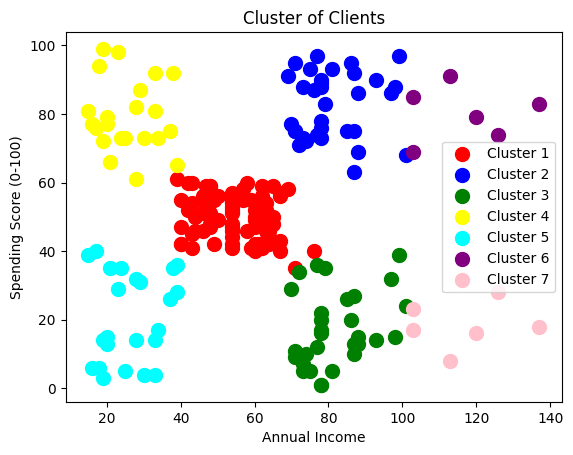

In [34]:
# Visualizing the clusters

n_clusters = len(np.unique(labels))
colors = ['red','blue','green','yellow','cyan','purple','pink']

for i in range(n_clusters):
  cluster = X[labels == i]
  plt.scatter(cluster[:,0], cluster[:,1], s=100, c=colors[i], label=f'Cluster {i+1}')
plt.title('Cluster of Clients')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score (0-100)')
plt.legend()
plt.show()